In [1]:
# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

# numpy: the foundation of numerical computing in Python
# used for array operations, reshaping images, math calculations
import numpy as np

# pandas: used for reading and manipulating the CSV dataset
# think of it like Excel but in Python
import pandas as pd

# matplotlib: used for visualizing images, graphs, and results
# pyplot is the specific module for creating plots
import matplotlib.pyplot as plt

# tensorflow: the main deep learning framework made by Google
# everything we build runs on tensorflow under the hood
import tensorflow as tf

# keras: a high-level, beginner-friendly API built on top of tensorflow
# it simplifies building neural networks with readable code
from tensorflow import keras

# Sequential: lets us build the model layer by layer, in order
# like stacking lego blocks on top of each other
from keras.models import Sequential

# the building blocks of our CNN:
# Conv2D          → scans images to detect features (edges, shapes)
# MaxPooling2D    → shrinks the image while keeping important info
# Dense           → fully connected layer for final classification
# Activation      → adds non-linearity (e.g. relu, softmax)
# Dropout         → randomly disables neurons to prevent overfitting
# Flatten         → converts 2D image data into a 1D list for Dense layers
# BatchNormalization → keeps values stable and speeds up training
from keras.layers import (Conv2D, MaxPooling2D, Dense,
                          Activation, Dropout, Flatten, BatchNormalization)

# ImageDataGenerator: used to artificially expand your dataset
# by randomly flipping, rotating, zooming images during training
# helps the model generalize better to new faces
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# train_test_split: splits our data into two groups
# training set (model learns from this) and test set (we evaluate on this)
# the model NEVER sees the test set during training
from sklearn.model_selection import train_test_split

2026-03-11 23:54:23.463797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773273263.647435      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773273263.700583      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773273264.164051      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773273264.164091      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773273264.164095      24 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================================
# STEP 3: LOAD & EXPLORE THE DATASET (folder version)
# ============================================================

import os

# define the paths to train and test folders
# kaggle datasets are always found under /kaggle/input/
TRAIN_DIR = '/kaggle/input/datasets/msambare/fer2013/train'
TEST_DIR  = '/kaggle/input/datasets/msambare/fer2013/test'

# ============================================================
# check what emotion folders exist inside train
# each subfolder name IS the emotion label
# e.g. /train/happy/ contains all happy face images
# ============================================================
emotion_folders = sorted(os.listdir(TRAIN_DIR))
print("Emotion classes found:", emotion_folders)
print("Total classes:", len(emotion_folders))

Emotion classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total classes: 7


In [3]:
# this prints a heading so the output is easy to read
# \n adds a blank line before it
print("\nImage counts per emotion (Training set):")

# create an empty dictionary to store our results
# a dictionary holds key-value pairs, like: {"happy": 7215, "sad": 4830}
# we'll fill it in the loop below
counts = {}

# loop through each emotion folder one at a time
# emotion_folders = ['angry', 'disgust', 'fear', 'happy', ...]
# each time the loop runs, 'emotion' = one folder name e.g. "happy"
for emotion in emotion_folders:

    # build the full path to that emotion's folder
    # os.path.join safely combines folder paths for any operating system
    # e.g. '/kaggle/input/fer2013/train' + 'happy'
    #    = '/kaggle/input/fer2013/train/happy'
    folder_path = os.path.join(TRAIN_DIR, emotion)

    # os.listdir() returns a list of every file inside that folder
    # e.g. ['img1.jpg', 'img2.jpg', 'img3.jpg', ...]
    # len() counts how many files are in that list = number of images
    num_images = len(os.listdir(folder_path))

    # store the result in our dictionary
    # key   = emotion name  e.g. "happy"
    # value = image count   e.g. 7215
    # after the loop: counts = {"angry": 3995, "happy": 7215, ...}
    counts[emotion] = num_images

    # print one line per emotion
    # :10s means "pad the emotion name to 10 characters wide" so columns line up neatly
    # e.g.   "angry      → 3995 images"
    #        "happy      → 7215 images"
    print(f"  {emotion:10s} → {num_images} images")

# after the loop is done, add up ALL values in the dictionary
# sum(counts.values()) = 3995 + 436 + 4097 + 7215 + ...
# gives us the total number of training images across all emotions
print("\nTotal training images:", sum(counts.values()))


Image counts per emotion (Training set):
  angry      → 3995 images
  disgust    → 436 images
  fear       → 4097 images
  happy      → 7215 images
  neutral    → 4965 images
  sad        → 4830 images
  surprise   → 3171 images

Total training images: 28709


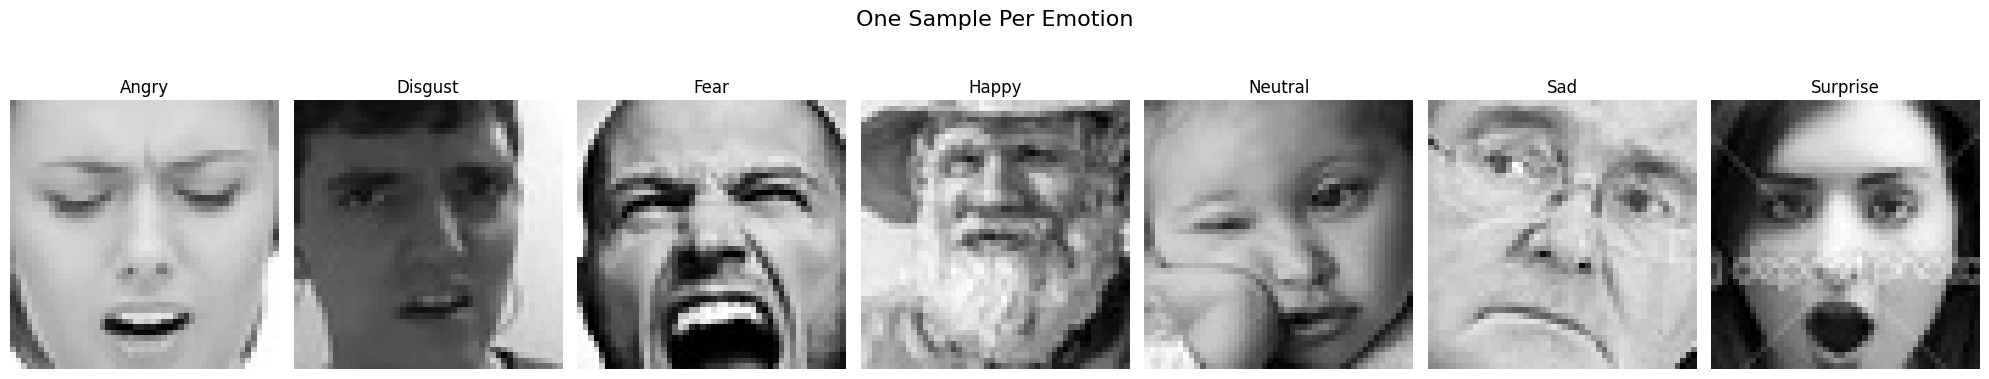

In [4]:
# ============================================================
# STEP 4: VISUALIZE SAMPLE IMAGES FROM THE DATASET
# ============================================================

# we always visualize data before training
# reason: confirms images loaded correctly, helps you understand
# what the model will actually be learning from

import matplotlib.image as mpimg

# ============================================================
# 4A. show one sample image from EACH emotion
# ============================================================

# how many emotions we have
num_emotions = len(emotion_folders)

# create a figure with 1 row and 7 columns (one column per emotion)
# figsize=(20, 4) makes it wide enough to fit all 7 side by side
fig, axes = plt.subplots(1, num_emotions, figsize=(20, 4))

# loop through each emotion and its corresponding plot slot
# enumerate gives us both the index (i) and the value (emotion)
# i     = 0, 1, 2, 3, 4, 5, 6
# emotion = 'angry', 'disgust', 'fear', ...
for i, emotion in enumerate(emotion_folders):

    # build path to this emotion's folder
    folder_path = os.path.join(TRAIN_DIR, emotion)

    # pick the very first image in the folder
    first_image_name = os.listdir(folder_path)[0]

    # build the full path to that image file
    image_path = os.path.join(folder_path, first_image_name)

    # read the image from disk into a numpy array
    # the array contains pixel values e.g. [[120, 45, 200], [80, 90, 110]...]
    img = mpimg.imread(image_path)

    # display the image in the correct subplot slot
    # cmap='gray' renders it as a grayscale image (black & white)
    axes[i].imshow(img, cmap='gray')

    # set the title below each image to the emotion name
    # .capitalize() makes first letter uppercase e.g. 'happy' → 'Happy'
    axes[i].set_title(emotion.capitalize(), fontsize=12)

    # remove the x and y axis ticks — they add no value for images
    axes[i].axis('off')

plt.suptitle('One Sample Per Emotion', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

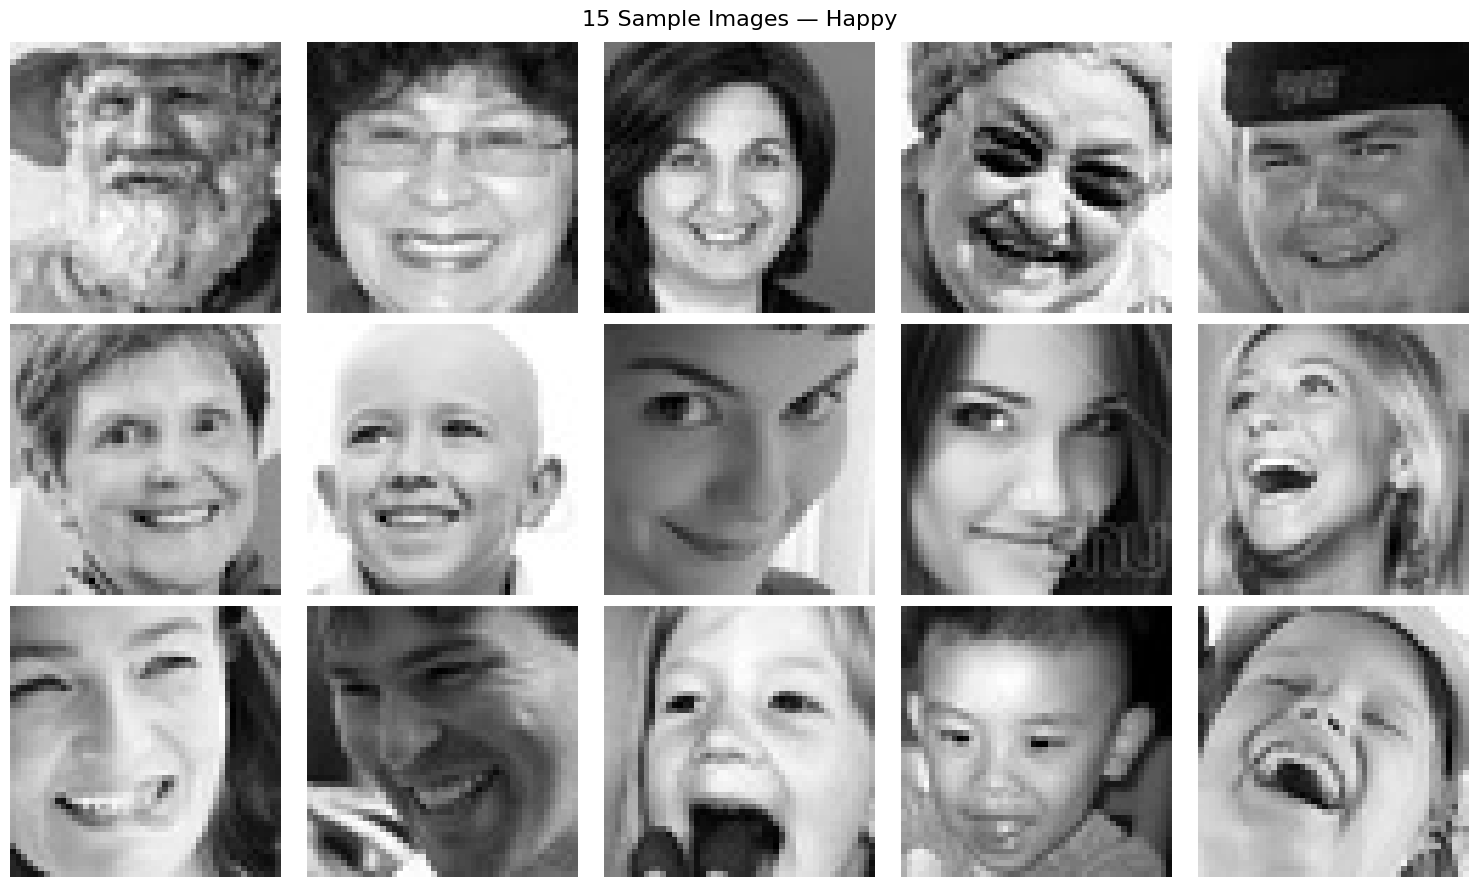

In [5]:
# ============================================================
# 4B. show multiple samples of the SAME emotion in a grid
# this helps you see how varied the images are within one class
# e.g. "happy" faces can look very different from each other
# ============================================================

emotion_to_explore = 'happy'   # ← change this to any emotion you want

folder_path  = os.path.join(TRAIN_DIR, emotion_to_explore)
image_files  = os.listdir(folder_path)

# show a 3x5 grid = 15 sample images from this emotion
rows, cols = 3, 5

fig, axes = plt.subplots(rows, cols, figsize=(15, 9))

# axes.flat lets us loop through all subplots as a single flat list
# instead of a 2D grid, making it easier to fill one by one
for i, ax in enumerate(axes.flat):

    # load the i-th image from this emotion folder
    img_path = os.path.join(folder_path, image_files[i])
    img      = mpimg.imread(img_path)

    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'15 Sample Images — {emotion_to_explore.capitalize()}', 
             fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 4C. check the image dimensions
# this is critical — our model expects exactly (48, 48) images
# if the size is different, we'll need to resize in the next step
# ============================================================

# check dimensions of one image from each emotion
print("Image dimensions per emotion:")
print("-" * 35)

for emotion in emotion_folders:
    folder_path      = os.path.join(TRAIN_DIR, emotion)
    sample_img_path  = os.path.join(folder_path, os.listdir(folder_path)[0])
    img              = mpimg.imread(sample_img_path)

    # img.shape returns (height, width) for grayscale
    # or (height, width, channels) for color images
    print(f"  {emotion:10s} → shape: {img.shape}")

Image dimensions per emotion:
-----------------------------------
  angry      → shape: (48, 48)
  disgust    → shape: (48, 48)
  fear       → shape: (48, 48)
  happy      → shape: (48, 48)
  neutral    → shape: (48, 48)
  sad        → shape: (48, 48)
  surprise   → shape: (48, 48)


In [7]:
# ============================================================
# STEP 5: PREPROCESS THE IMAGES (6 classes, no disgust)
# ============================================================

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# 5A. DEFINE SETTINGS
# ============================================================

IMG_SIZE    = 48   # all images are already 48x48 — confirmed in step 4
BATCH_SIZE  = 64   # number of images processed at one time
NUM_CLASSES = 6    # we removed disgust, so 6 emotions remain

# our 6 emotions — disgust is excluded
EMOTIONS = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print("Settings:")
print(f"  Image size  : {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Num classes : {NUM_CLASSES}")
print(f"  Emotions    : {EMOTIONS}")

Settings:
  Image size  : 48x48 pixels
  Batch size  : 64
  Num classes : 6
  Emotions    : ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [8]:
# ============================================================
# 5B. CREATE IMAGE DATA GENERATORS
# ============================================================

# training generator — normalize + augment
train_datagen = ImageDataGenerator(
    rescale=1./255,         # normalize pixel values 0-255 → 0.0-1.0
    rotation_range=10,      # randomly rotate up to 10 degrees
    width_shift_range=0.1,  # randomly shift left/right by 10%
    height_shift_range=0.1, # randomly shift up/down by 10%
    horizontal_flip=True,   # randomly mirror left ↔ right
    zoom_range=0.1          # randomly zoom in/out by 10%
)

# test generator — only normalize, never augment
test_datagen = ImageDataGenerator(rescale=1./255)

print("Generators created ✓")

Generators created ✓


In [9]:
# ============================================================
# 5C. LOAD IMAGES FROM FOLDERS
# the 'classes' parameter tells the generator to ONLY load
# our 6 emotions — disgust folder is automatically ignored
# no copying or deleting needed!
# ============================================================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTIONS,
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTIONS,
    shuffle=False
)

# wrap both generators so they loop forever
# this prevents the "ran out of data" error
train_dataset = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 6),         dtype=tf.float32)
    )
).repeat()

test_dataset = tf.data.Dataset.from_generator(
    lambda: test_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 6),         dtype=tf.float32)
    )
).repeat()

print("Class mapping:", train_generator.class_indices)
print("Fixed datasets ready ✓")

Found 28273 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Class mapping: {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}
Fixed datasets ready ✓


I0000 00:00:1773273315.135036      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [10]:
# ============================================================
# 5D. VERIFY EVERYTHING IS CORRECT BEFORE BUILDING THE MODEL
# ============================================================

sample_images, sample_labels = next(train_generator)

print("Image batch shape :", sample_images.shape)
# ✅ should be (64, 48, 48, 1)

print("Label batch shape :", sample_labels.shape)
# ✅ should be (64, 6)  ← 6 not 7!

print("Pixel value range :", round(sample_images.min(), 2),
      "to", round(sample_images.max(), 2))

Image batch shape : (64, 48, 48, 1)
Label batch shape : (64, 6)
Pixel value range : 0.0 to 1.0


In [11]:
# ============================================================
# STEP 6: BUILD THE CNN MODEL
#
# CNN = Convolutional Neural Network
# specially designed for images — it learns to detect:
#   Block 1 → simple patterns  (edges, lines)
#   Block 2 → medium patterns  (eyes, nose shape)
#   Block 3 → complex patterns (full facial expressions)
# ============================================================

from keras.models import Sequential
from keras.layers import (Conv2D, MaxPooling2D, Dense,
                          Activation, Dropout, Flatten, 
                          BatchNormalization)

def build_model():
    # Sequential means layers are stacked one after another
    # like an assembly line — each layer processes the output of the previous
    model = Sequential()

    # --------------------------------------------------------
    # BLOCK 1: detect simple features (edges, corners)
    # input image is 48x48x1 (width x height x grayscale channel)
    # --------------------------------------------------------

    # Conv2D scans the image with a 5x5 filter looking for patterns
    # 64 = number of different patterns/filters to learn
    # padding='same' keeps the output the same size as input
    model.add(Conv2D(64,(5,5),padding='same',
                    input_shape=(IMG_SIZE,IMG_SIZE,1)))
    model.add(Activation('relu'))
    # relu = "Rectified Linear Unit"
    # it simply turns all negative values to 0
    # why? negative values don't represent useful features
    # formula: output = max(0, input)

    model.add(Conv2D(64,(5,5),padding='same'))
    model.add(Activation('relu'))
    # BatchNormalization keeps the values in a stable range
    # prevents values from getting too large or too small
    # makes training faster and more stable
    model.add(BatchNormalization())

    # MaxPooling shrinks the image by taking the maximum value
    # in each 2x2 block of pixels
    # 48x48 → 24x24  (half the size)
    # why? reduces computation and focuses on strongest features
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Dropout randomly turns off 25% of neurons during training
    # why? prevents the model from memorizing training data
    # forces it to learn more general patterns
    model.add(Dropout(0.25))

    # --------------------------------------------------------
    # BLOCK 2: detect medium features (eyes, mouth curves)
    # 128 filters = learns more complex patterns than block 1
    # --------------------------------------------------------

    model.add(Conv2D(128,(5,5),padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(128,(5,5),padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())

    # 24x24 → 12x12
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    # --------------------------------------------------------
    # BLOCK 3: detect complex features (full expressions)
    # 256 filters = most complex patterns
    # smaller 3x3 filter = captures fine details
    # --------------------------------------------------------

    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())

    # 12x12 → 6x6
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))


    # -------------------------------------------------------
    # BLOCK 4 — new! learns even more complex features
    # -------------------------------------------------------
    model.add(Conv2D(512, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(512, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    # --------------------------------------------------------
    # CLASSIFIER: convert learned features into a prediction
    # --------------------------------------------------------

    # Flatten converts the 3D output (6x6x256) into a 1D list
    # 6 x 6 x 256 = 9216 numbers in a single row
    # Dense layers need 1D input, not 3D
    model.add(Flatten())

    model.add(Flatten())

    model.add(Dense(256))          # bigger than before (was 128)
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    # Dense = fully connected layer
    # every neuron connects to every input
    # 128 neurons learn combinations of all features detected above
    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # stronger dropout before final layer
    # 50% of neurons turned off — forces robust learning
    model.add(Dropout(0.5))

    # final output layer — one neuron per emotion (6 total)
    model.add(Dense(NUM_CLASSES))

    # softmax converts raw numbers into probabilities that sum to 1
    # e.g. [0.72, 0.02, 0.05, 0.08, 0.10, 0.03]
    #       angry  fear  happy neut  sad   surp
    model.add(Activation('softmax'))

    # --------------------------------------------------------
    # COMPILE: define how the model learns
    # --------------------------------------------------------
    model.compile(
        # categorical_crossentropy measures how wrong the prediction is
        # e.g. predicted "fear" with 90% confidence but answer was "happy"
        # → high loss. model adjusts weights to do better next time
        loss='categorical_crossentropy',

        # adam automatically adjusts the learning rate during training
        # learning rate = how big a step to take when correcting mistakes
        optimizer='adam',

        # accuracy = % of correct predictions, shown during training
        metrics=['accuracy']
    )

    return model

# build the model
model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# ============================================================
# STEP 7: TRAIN THE MODEL
# ============================================================

from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# ============================================================
# 7A. SET UP CALLBACKS
#
# callbacks are helper functions that run automatically
# after each epoch — think of them as training assistants
# ============================================================

# CALLBACK 1: ModelCheckpoint
# saves the model to a file after every epoch
# but ONLY if validation accuracy improved
# so we always keep the BEST version of the model
checkpoint = ModelCheckpoint(
    'best_model.h5',          # save to this file
    monitor='val_accuracy',   # watch validation accuracy
    save_best_only=True,      # only save if it improved
    verbose=1                 # print a message when saved
)

# CALLBACK 2: ReduceLROnPlateau
# learning rate = how big a step to take when fixing weights
# if the model stops improving for 3 epochs → halve the learning rate
# why? smaller steps help the model find better solutions
#      like slowing down when you're close to a destination
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # watch validation loss
    factor=0.5,           # multiply learning rate by 0.5 (halve it)
    patience=3,           # wait 3 epochs before reducing
    min_lr=1e-6,          # never go below this learning rate
    verbose=1             # print a message when reduced
)

# CALLBACK 3: EarlyStopping
# if validation accuracy doesn't improve for 5 epochs in a row
# stop training automatically — no point continuing
# why? saves time and prevents overfitting
early_stop = EarlyStopping(
    monitor='val_accuracy',  # watch validation accuracy
    patience=5,              # wait 5 epochs before stopping
    restore_best_weights=True, # go back to best weights when stopped
    verbose=1
)

print("Callbacks ready ✓")

Callbacks ready ✓


In [13]:
# ============================================================
# 7B. CALCULATE STEPS PER EPOCH
#
# the generator sends images in batches of 64
# we need to tell the model how many batches = 1 full epoch
#
# steps = total images ÷ batch size
# e.g. 28273 images ÷ 64 per batch = 442 batches per epoch
# after 442 batches the model has seen ALL training images once
# ============================================================

train_steps = train_generator.samples // BATCH_SIZE
test_steps  = test_generator.samples  // BATCH_SIZE

print(f"Training images    : {train_generator.samples}")
print(f"Test images        : {test_generator.samples}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Train steps/epoch  : {train_steps}")
print(f"Test steps/epoch   : {test_steps}")

Training images    : 28273
Test images        : 7067
Batch size         : 64
Train steps/epoch  : 441
Test steps/epoch   : 110


In [14]:
# ============================================================
# 7C. TRAIN THE MODEL
#
# this is where the actual learning happens
# the model will see every training image once per epoch
# and adjust its weights to reduce the loss
# ============================================================

# FIXED — rebuild model + use new datasets
# rebuild model so weights start fresh
model = build_model()

history = model.fit(
    train_dataset,                # ← new fixed dataset
    steps_per_epoch=train_steps,
    epochs=60,
    validation_data=test_dataset, # ← new fixed dataset
    validation_steps=test_steps,
    callbacks=[
        ModelCheckpoint('best_model.keras',
                        monitor='val_accuracy',
                        save_best_only=True,
                        verbose=1),
        ReduceLROnPlateau(monitor='val_loss',
                          factor=0.5,
                          patience=3,
                          min_lr=1e-6,
                          verbose=1),
        EarlyStopping(monitor='val_accuracy',
                      patience=5,
                      restore_best_weights=True,
                      verbose=1)
    ]
)

# model.fit returns a 'history' object
# it records accuracy and loss after every epoch
# we'll use it in step 8 to plot the learning curves

Epoch 1/60


I0000 00:00:1773273323.440174      80 service.cc:152] XLA service 0x137ccc80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773273323.440214      80 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773273324.532046      80 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/441 ━━━━━━━━━━━━━━━━━━━━ 2:05:39 17s/step - accuracy: 0.2656 - loss: 2.4317

I0000 00:00:1773273335.206266      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.2007 - loss: 2.0680
Epoch 1: val_accuracy improved from -inf to 0.27031, saving model to best_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 281s 600ms/step - accuracy: 0.2008 - loss: 2.0677 - val_accuracy: 0.2703 - val_loss: 1.7134 - learning_rate: 0.0010
Epoch 2/60
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2646 - loss: 1.7715
Epoch 2: val_accuracy improved from 0.27031 to 0.31858, saving model to best_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 56s 128ms/step - accuracy: 0.2646 - loss: 1.7714 - val_accuracy: 0.3186 - val_loss: 1.6496 - learning_rate: 0.0010
Epoch 3/60
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3230 - loss: 1.6538
Epoch 3: val_accuracy improved from 0.31858 to 0.39012, saving model to best_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.3230 - loss: 1.6537 - val_accuracy: 0.3901 - val_loss: 1.5058 - learning_rate: 0.0010
Epoch 4/60
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step 

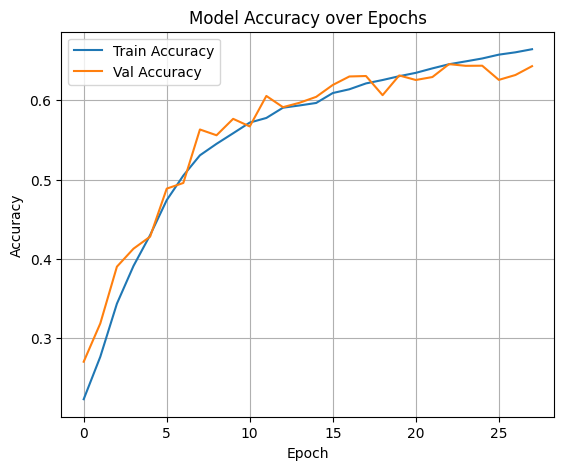

In [15]:
# ============================================================
# STEP 8: PLOT TRAINING RESULTS
#
# remember 'history' recorded everything during training
# now we visualize it so we can understand what happened
# ============================================================

# 8A. ACCURACY PLOT
# shows how accuracy changed every epoch
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# ^^^^^^^^^^^^^^^^^^
# subplot(rows, cols, position)
# 1 row, 2 columns, this is plot number 1
# puts accuracy and loss side by side

plt.plot(history.history['accuracy'], label='Train Accuracy')
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# history.history['accuracy'] = list of training accuracy
# for every epoch
# e.g. [0.23, 0.33, 0.41, 0.51, ...]
# plt.plot draws a line connecting all these points

plt.plot(history.history['val_accuracy'], label='Val Accuracy')
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# val_accuracy = accuracy on test images
# this is the REAL measure of performance
# model never trained on these images

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
# what the x axis represents (epoch number)

plt.ylabel('Accuracy')
# what the y axis represents (accuracy 0.0 to 1.0)

plt.legend()
# shows the colored key explaining which line is which
# "Train Accuracy" and "Val Accuracy"

plt.grid(True)
# adds faint grid lines — makes it easier to read values

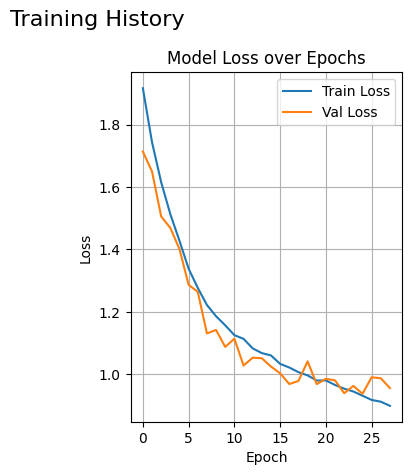

In [16]:
# ============================================================
# 8B. LOSS PLOT
# shows how loss changed every epoch
# loss = how wrong the model is
# we want this to go DOWN over time
# ============================================================

plt.subplot(1, 2, 2)
# position 2 — right side of the figure

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('Training History', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 8C. PRINT BEST RESULTS SUMMARY
# ============================================================

best_val_acc   = max(history.history['val_accuracy'])
best_epoch     = history.history['val_accuracy'].index(best_val_acc) + 1
final_val_acc  = history.history['val_accuracy'][-1]
final_train_acc= history.history['accuracy'][-1]

print("=" * 40)
print("       TRAINING SUMMARY")
print("=" * 40)

print(f"Total epochs trained    : {len(history.history['accuracy'])}")
print(f"Best val accuracy       : {best_val_acc*100:.2f}%  (epoch {best_epoch})")
print(f"Final train accuracy    : {final_train_acc*100:.2f}%")
print(f"Final val accuracy      : {final_val_acc*100:.2f}%")

# gap between train and val accuracy
# large gap = overfitting
gap = final_train_acc - final_val_acc
print(f"Train/Val gap           : {gap*100:.2f}%")

print("=" * 40)

if gap < 0.05:
    print("✅ small gap — model is generalizing well")
elif gap < 0.15:
    print("⚠️  medium gap — slight overfitting")
else:
    print("❌ large gap — model is overfitting")


       TRAINING SUMMARY
Total epochs trained    : 28
Best val accuracy       : 64.54%  (epoch 23)
Final train accuracy    : 66.42%
Final val accuracy      : 64.29%
Train/Val gap           : 2.14%
✅ small gap — model is generalizing well


In [18]:
# ============================================================
# STEP 9: EVALUATE THE MODEL
#
# accuracy alone doesn't tell the full story
# we need to know:
#   - which emotions does it get RIGHT?
#   - which emotions does it CONFUSE with each other?
#   - is it biased toward any one emotion?
# ============================================================

# 9A. OVERALL ACCURACY ON TEST SET
# ============================================================

# load the best saved model
from keras.models import load_model

model = load_model('best_model.keras')
print("Best model loaded ✓")

# evaluate on test images
# this runs through all 7,178 test images
# and returns overall loss and accuracy
loss, accuracy = model.evaluate(test_dataset, steps=test_steps, verbose=1)

print(f"\nFinal Test Loss     : {loss:.4f}")
print(f"Final Test Accuracy : {accuracy*100:.2f}%")

Best model loaded ✓
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.6879 - loss: 0.8135

Final Test Loss     : 0.9418
Final Test Accuracy : 64.54%


In [19]:
# ============================================================
# 9B. GET PREDICTIONS FOR ALL TEST IMAGES
#
# we need the actual predictions vs correct answers
# to build a detailed breakdown
# ============================================================

import numpy as np

# reset generator so it starts from the beginning
# important! otherwise predictions won't match labels
test_generator.reset()

# predict on ALL test images
# steps=test_steps means go through all 7,178 images
print("Generating predictions...")
predictions = model.predict(test_dataset, steps=test_steps, verbose=1)

# predictions looks like this for each image:
# [0.02, 0.05, 0.85, 0.03, 0.02, 0.03]
#  angry fear  happy neut  sad   surp
# we need the INDEX of the highest value = predicted class
y_pred = np.argmax(predictions, axis=1)
# e.g. [2, 0, 4, 2, 5, 3, ...]  ← predicted emotion numbers

# get the TRUE labels for all test images
# test_generator.classes = the correct answer for each image
y_true = test_generator.classes[:len(y_pred)]
# e.g. [2, 0, 4, 2, 5, 3, ...]  ← correct emotion numbers

print(f"\nTotal predictions made: {len(y_pred)}")
print("Predictions ready ✓")

Generating predictions...
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step

Total predictions made: 7040
Predictions ready ✓


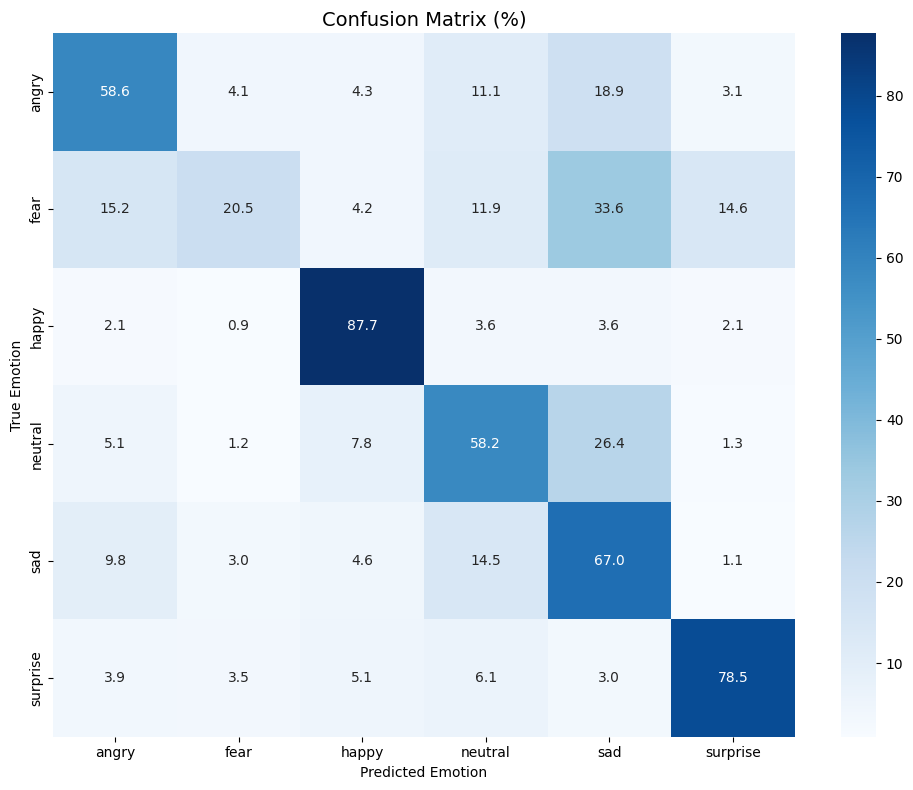

In [20]:
# ============================================================
# 9C. CONFUSION MATRIX
#
# a confusion matrix shows us exactly which emotions
# the model confuses with each other
#
# rows    = correct emotion (what it SHOULD predict)
# columns = predicted emotion (what it ACTUALLY predicted)
# diagonal = correct predictions (what we want high)
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# normalize so each row adds up to 100%
# this makes it easier to compare across emotions
# that have different numbers of images
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# plot it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_percent,
    annot=True,           # show numbers inside each cell
    fmt='.1f',            # show 1 decimal place e.g. 72.3
    cmap='Blues',         # blue color scheme
    xticklabels=EMOTIONS, # column labels = predicted emotions
    yticklabels=EMOTIONS  # row labels = true emotions
)

plt.title('Confusion Matrix (%)', fontsize=14)
plt.ylabel('True Emotion')    # correct answer
plt.xlabel('Predicted Emotion') # model prediction
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# 9D. PER EMOTION ACCURACY
#
# breaks down accuracy for each individual emotion
# tells us which emotions the model is good/bad at
# ============================================================

print("\nAccuracy per emotion:")
print("─" * 35)

per_emotion_accuracy = {}

for i, emotion in enumerate(EMOTIONS):
    # find all test images that are truly this emotion
    # np.where returns indices where condition is true
    true_indices = np.where(y_true == i)[0]

    # count how many of those the model got correct
    correct = np.sum(y_pred[true_indices] == i)

    # calculate accuracy for this emotion
    emotion_accuracy = correct / len(true_indices) * 100
    per_emotion_accuracy[emotion] = emotion_accuracy

    print(f"  {emotion:10s} → {emotion_accuracy:.1f}%  ({correct}/{len(true_indices)} correct)")

print("─" * 35)
print(f"  {'Overall':10s} → {accuracy*100:.1f}%")


Accuracy per emotion:
───────────────────────────────────
  angry      → 58.6%  (561/958 correct)
  fear       → 20.5%  (210/1024 correct)
  happy      → 87.7%  (1556/1774 correct)
  neutral    → 58.2%  (717/1233 correct)
  sad        → 67.0%  (835/1247 correct)
  surprise   → 78.5%  (631/804 correct)
───────────────────────────────────
  Overall    → 64.5%


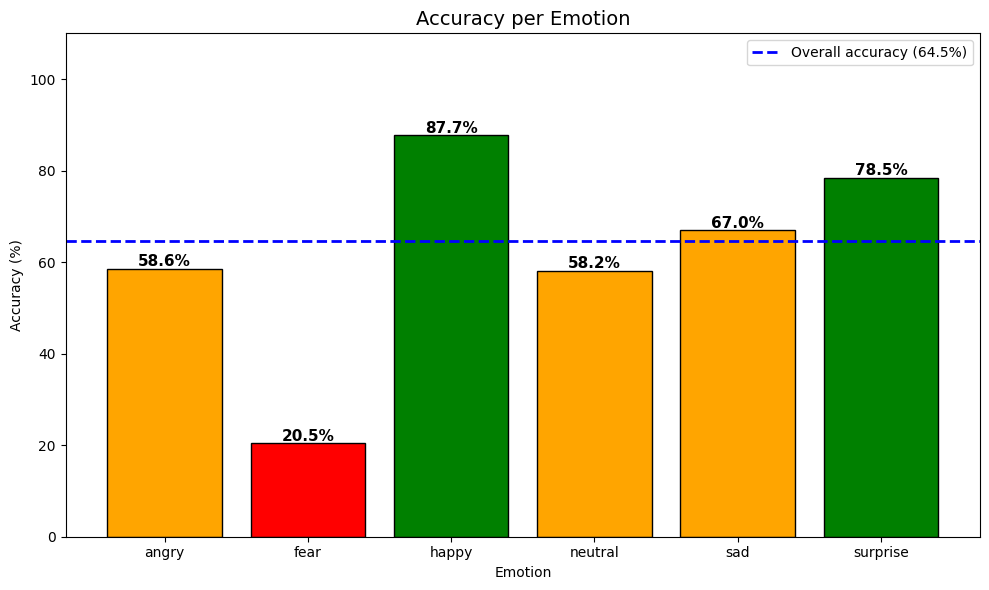

In [22]:
# ============================================================
# 9E. VISUALIZE PER EMOTION ACCURACY AS BAR CHART
# ============================================================

emotions   = list(per_emotion_accuracy.keys())
accuracies = list(per_emotion_accuracy.values())

# color bars based on performance
# green = good (above 70%)
# orange = okay (50-70%)
# red = poor (below 50%)
colors = []
for acc in accuracies:
    if acc >= 70:
        colors.append('green')
    elif acc >= 50:
        colors.append('orange')
    else:
        colors.append('red')

plt.figure(figsize=(10, 6))
bars = plt.bar(emotions, accuracies, color=colors, edgecolor='black')

# add accuracy percentage on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.1f}%',
             ha='center', fontsize=11, fontweight='bold')

# add a horizontal line showing overall accuracy
plt.axhline(y=accuracy*100, color='blue',
            linestyle='--', linewidth=2,
            label=f'Overall accuracy ({accuracy*100:.1f}%)')

plt.title('Accuracy per Emotion', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()